In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/alzheimers_disease_data.csv')
print(df)

      PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0          4751   73       0          0               2  22.927749        0   
1          4752   89       0          0               0  26.827681        0   
2          4753   73       0          3               1  17.795882        0   
3          4754   74       1          0               1  33.800817        1   
4          4755   89       0          0               0  20.716974        0   
...         ...  ...     ...        ...             ...        ...      ...   
2144       6895   61       0          0               1  39.121757        0   
2145       6896   75       0          0               2  17.857903        0   
2146       6897   77       0          0               1  15.476479        0   
2147       6898   78       1          3               1  15.299911        0   
2148       6899   72       0          0               2  33.289738        0   

      AlcoholConsumption  PhysicalActivity  DietQua

In [ ]:
df['CognitiveScore'] = 0.6 * df['MMSE'] + 0.4 * df['FunctionalAssessment']


In [ ]:
#Check for null values
print(df.isnull().sum())

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
<ipython-input-5-b0430f693511>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.li

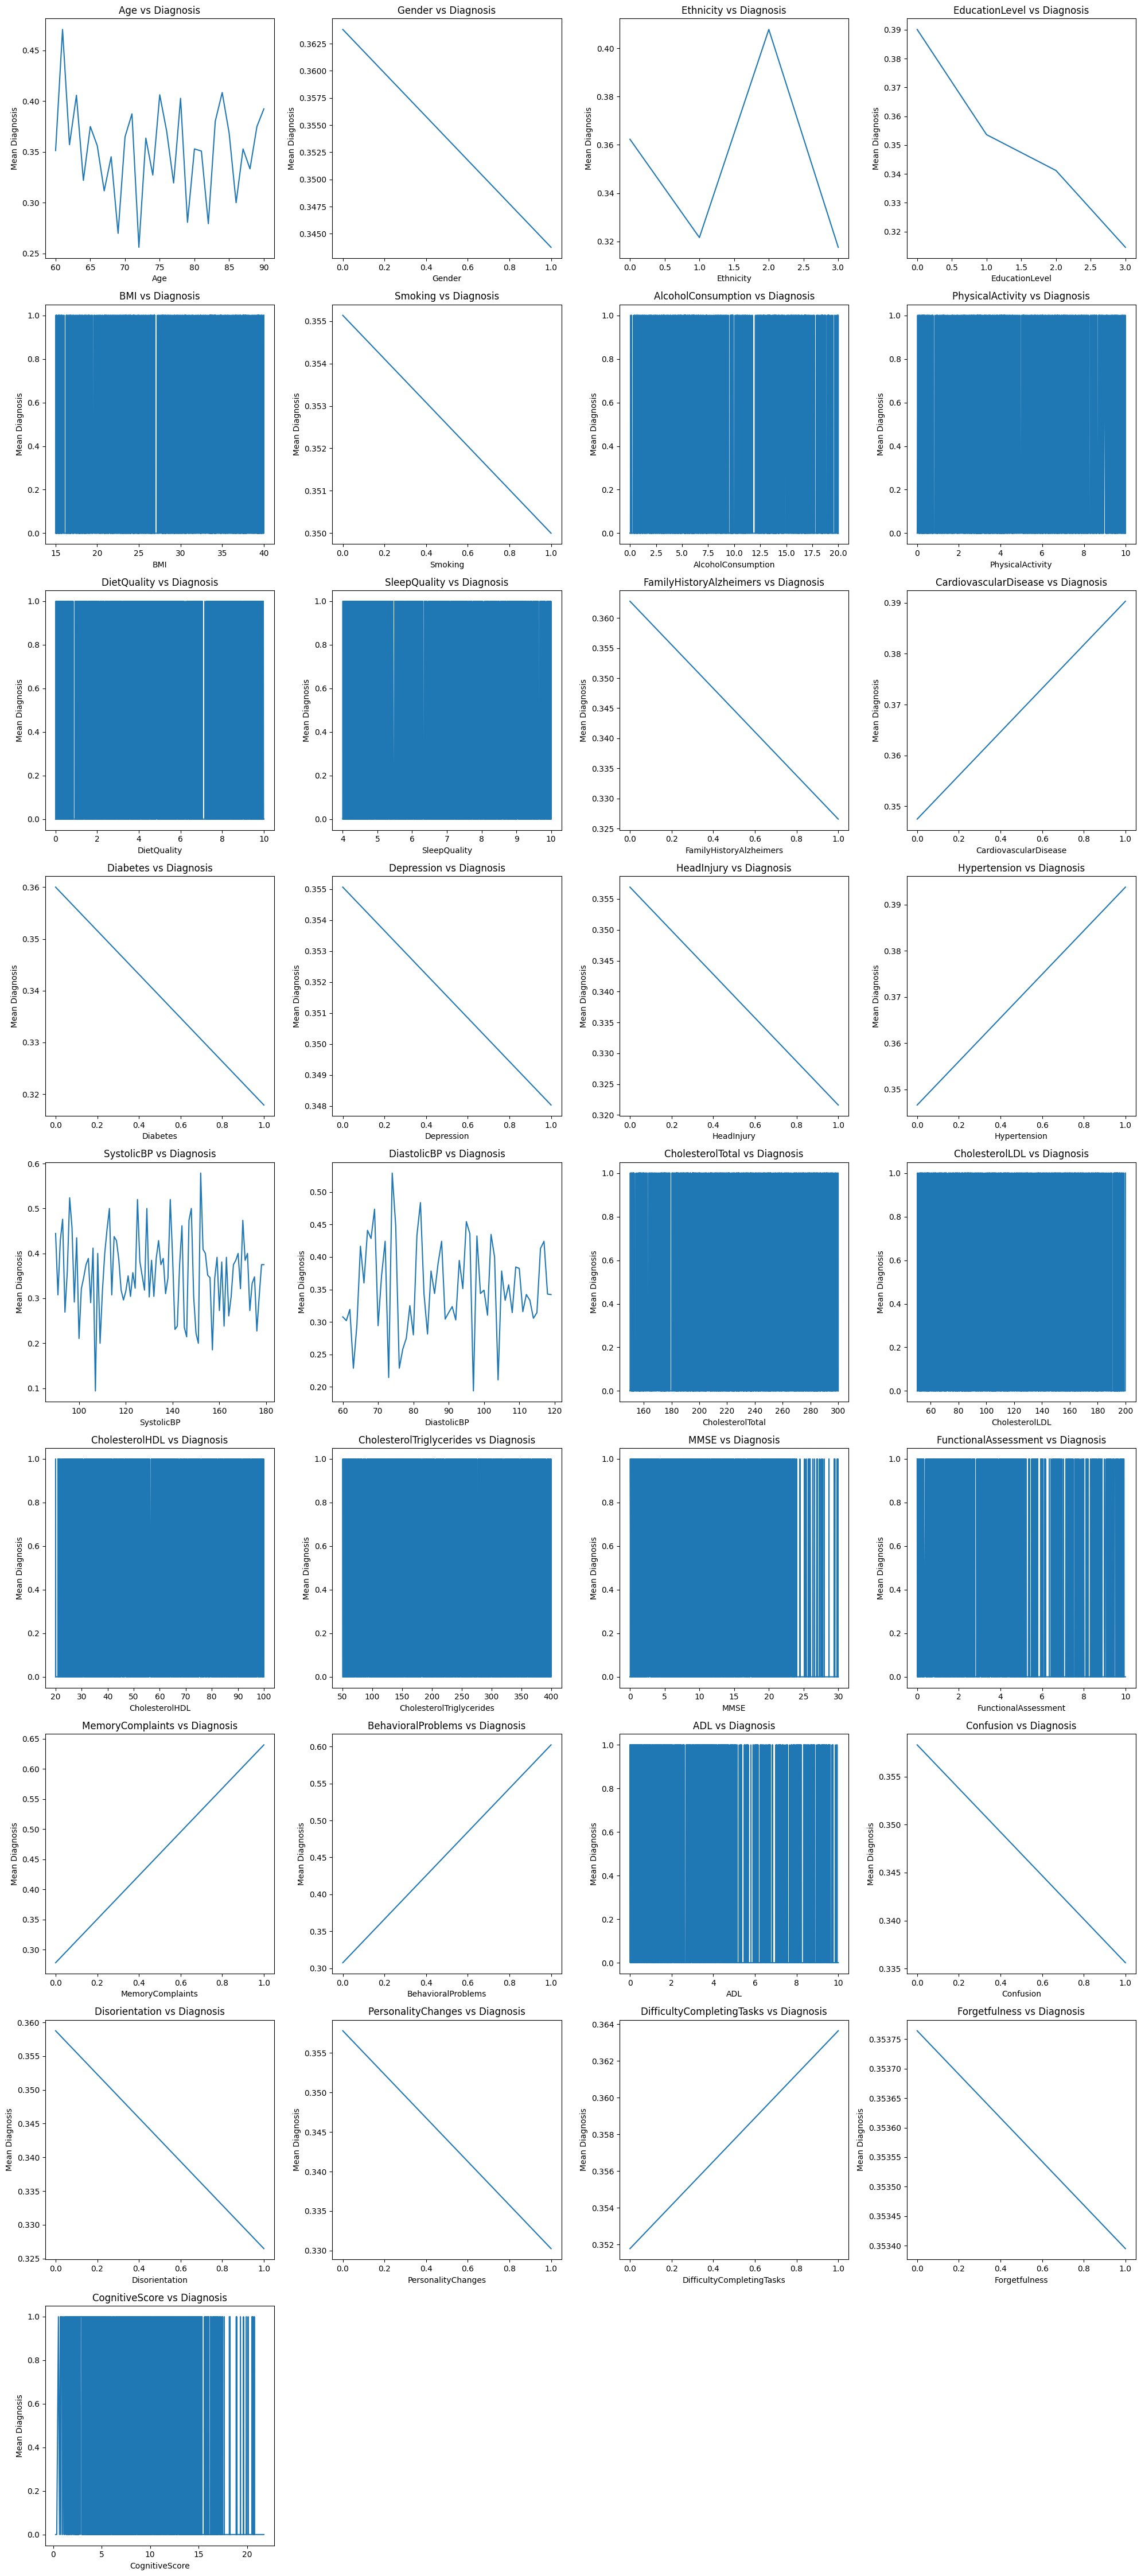

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['PatientID', 'Diagnosis']).columns

# Plotting setup
num_features = len(numeric_features)
cols = 4  # ek row mein 4 graph
rows = (num_features + cols - 1) // cols
plt.figure(figsize=(20, 5 * rows))

# Har feature ke liye line plot banao
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.lineplot(
        x=df[feature],
        y=df['Diagnosis'],
        ci=None,
        estimator='mean'  # average line plot
    )
    plt.title(f'{feature} vs Diagnosis')
    plt.xlabel(feature)
    plt.ylabel('Mean Diagnosis')

plt.tight_layout()
plt.show()

Dropping these columns: ['Diagnosis', 'DoctorInCharge']
Selected Features: Index(['PatientID', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'CognitiveScore'],
      dtype='object')
Chi-Square Scores for all features:
MMSE                         607.256596
CognitiveScore               535.720319
FunctionalAssessment         471.117684
ADL                          414.290935
PatientID                    238.892184
MemoryComplaints             160.142705
BehavioralProblems            91.203581
CholesterolTriglycerides      50.306694
CholesterolHDL                35.073008
CholesterolLDL                33.219382
SleepQuality                   3.029711
BMI                            2.807631
EducationLevel                 2.640277
SystolicBP                     2.626770
Hypertension                   2.250784
CardiovascularDisease          1.823618
Diabetes                     

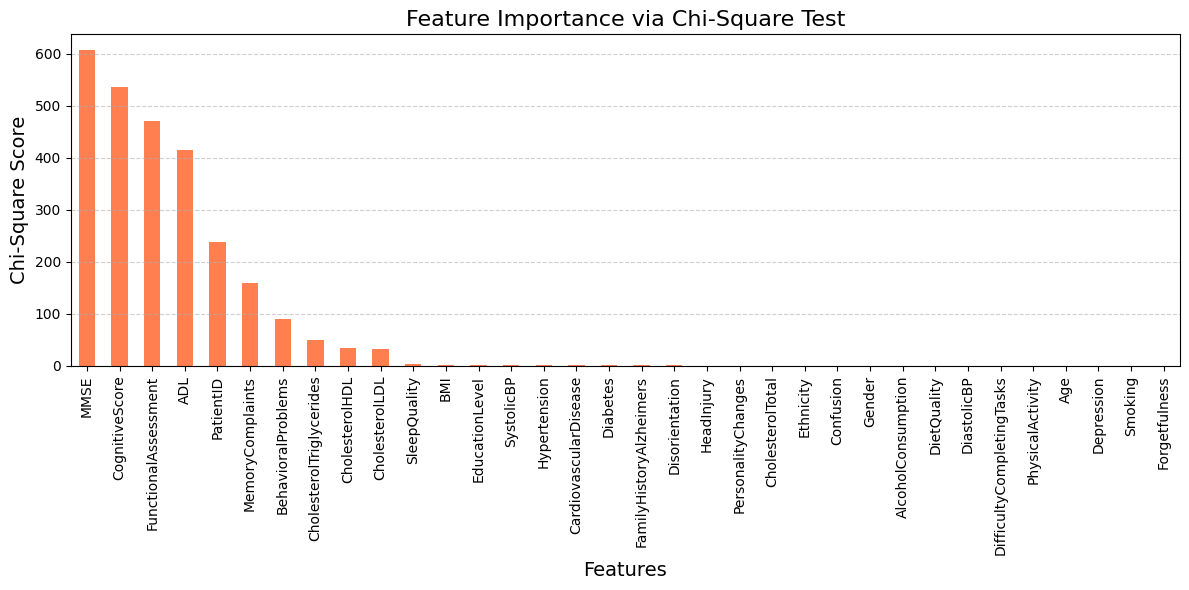

In [ ]:
#  Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2

#  Clean column names (optional but helpful)
df.columns = df.columns.str.strip()

#  Define columns to drop (including Patient_ID and DoctorInCharge)
columns_to_drop = ['Diagnosis','DoctorInCharge']  # Dropping both Diagnosis and DoctorInCharge

# Print columns being dropped
print("Dropping these columns:", columns_to_drop)

# Drop unwanted columns from the original DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

# Define features (x) and target (y)
x = df_cleaned  # Features without Patient_ID and Diagnosis
y = df['Diagnosis']  # Target is from the original df

#  Apply Chi2 feature selection (k=10 most important features)
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(x, y)

#  Get selected feature names
selected_features = x.columns[selector.get_support()]
print("Selected Features:", selected_features)

#  Plot the Chi-Square feature selection scores
chi2_scores = pd.Series(selector.scores_, index=x.columns).sort_values(ascending=False)

#  Print the top features based on Chi-Square score
print("Chi-Square Scores for all features:")
print(chi2_scores)

#  Plotting the Chi-Square scores for feature importance
plt.figure(figsize=(12, 6))
chi2_scores.plot(kind='bar', color='coral')
plt.title("Feature Importance via Chi-Square Test", fontsize=16)
plt.ylabel("Chi-Square Score", fontsize=14)
plt.xlabel("Features", fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Drop 'Patient_ID', 'DoctorInCharge', and 'Diagnosis' if they exist
columns_to_drop = ['Diagnosis', 'Patient_ID', 'DoctorInCharge']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Check columns after dropping to make sure 'Patient_ID' is gone
print("Columns after dropping Patient_ID:", df_cleaned.columns.tolist())
# Define features and target
features = df_cleaned.drop(columns=['Diagnosis'], errors='ignore')  # Drop Diagnosis from cleaned data
target = df['Diagnosis']  # Target is from the original df

# Check if Diagnosis is properly assigned to target
print("Features columns for MI:", features.columns.tolist())
print("Target (Diagnosis) column:", target.head())  # Check if target is correct


# Compute mutual information scores
mi_scores = mutual_info_classif(features, target, random_state=42)

# Create a sorted list of features by importance
mi_scores_series = pd.Series(mi_scores, index=features.columns).sort_values(ascending=False)

# Plot the mutual information scores
plt.figure(figsize=(12, 8))
mi_scores_series.plot(kind='bar', color='skyblue')
plt.title("Feature Importance via Mutual Information", fontsize=16)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Mutual Information Score", fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


KeyError: "['Patient_ID'] not found in axis"

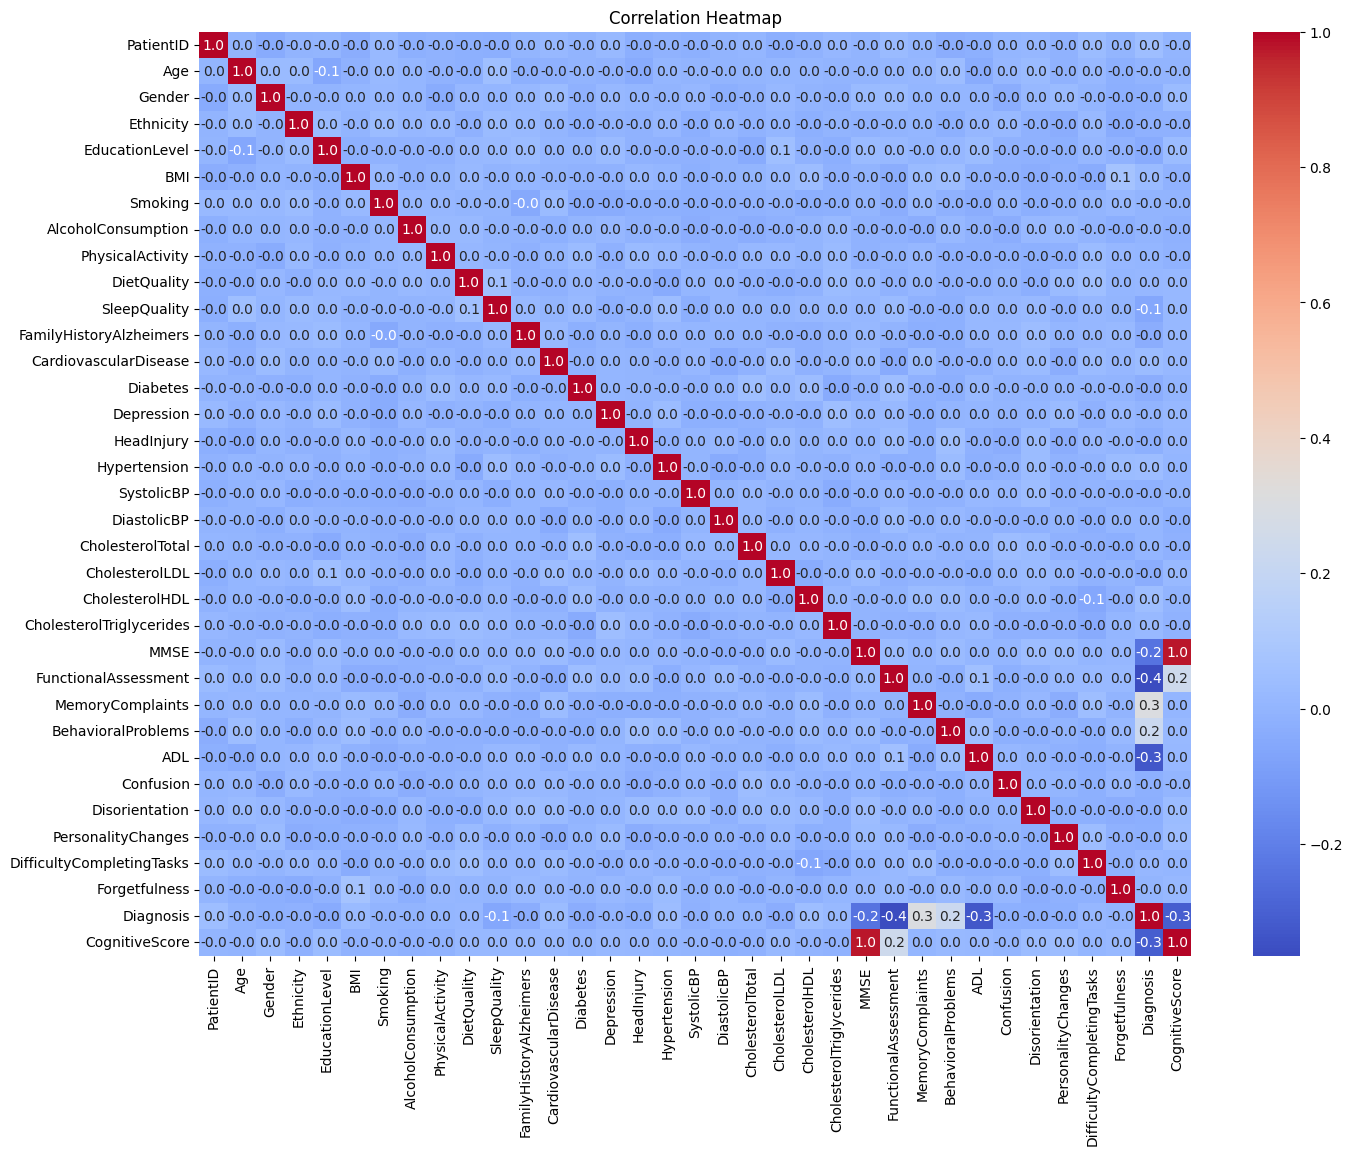

In [ ]:
# Drop all non-numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".1f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


<Figure size 1600x1200 with 0 Axes>

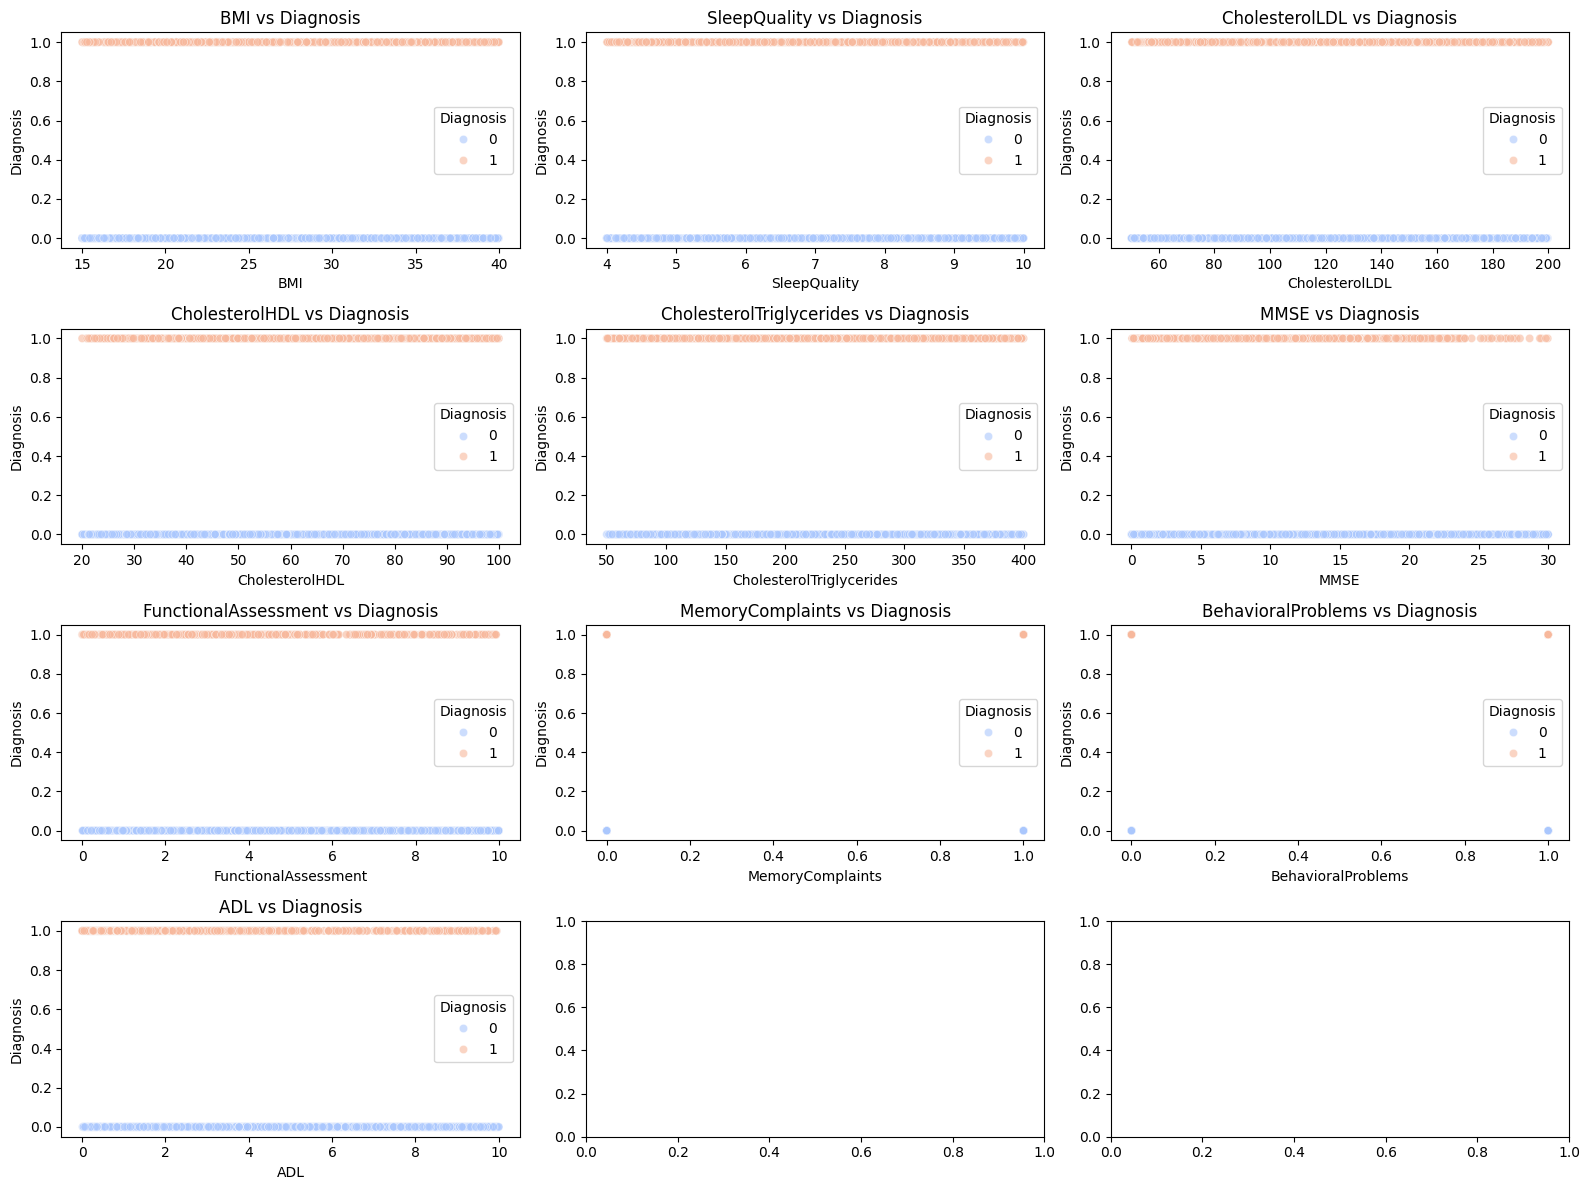

In [ ]:
# Scatter plots for selected features vs Diagnosis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
selected_features_for_scatter = ['BMI', 'SleepQuality', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL']

# Use the DataFrame where 'CognitiveScore' was added (x in this case)
# Adjust the subplot grid to accommodate all features (e.g., 4 rows, 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(16, 12))  # Changed to 4 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier iteration

for i, feature in enumerate(selected_features_for_scatter):
    sns.scatterplot(x=x[feature], y=y, hue=y, alpha=0.6, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

In [ ]:
#Check and handle class imbalance
from imblearn.over_sampling import SMOTE
print("Class distribution:\n", y.value_counts())
if y.value_counts()[0] / y.value_counts()[1] > 1.5:  # If imbalance exists
    smote = SMOTE(random_state=42)
    x, y = smote.fit_resample(x, y)

Class distribution:
 Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Split data (REPLACE your existing train_test_split)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled)
print(X_test_scaled)

[[ 0.18785579 -1.11311097 -0.91037709 ...  2.55634186  1.69712684
  -1.17873739]
 [ 1.13848264  0.37598651 -0.91037709 ... -0.39118399 -0.58923115
   0.426231  ]
 [-0.7563479  -0.88401905 -0.91037709 ... -0.39118399 -0.58923115
   0.69150158]
 ...
 [ 0.06581586  1.17780823 -0.91037709 ... -0.39118399 -0.58923115
   1.47581062]
 [ 0.32916519  1.63599206  1.09844591 ... -0.39118399 -0.58923115
  -0.86802093]
 [-0.36774706 -0.42583521 -0.91037709 ... -0.39118399 -0.58923115
  -0.48598925]]
[[-0.33723708  0.60507843  1.09844591 ... -0.39118399  1.69712684
  -0.99920861]
 [ 1.44679405 -0.65492713  1.09844591 ... -0.39118399 -0.58923115
   0.97320747]
 [-0.3211792   0.37598651  1.09844591 ... -0.39118399  1.69712684
   1.7112743 ]
 ...
 [-1.63150269 -1.11311097  1.09844591 ... -0.39118399 -0.58923115
  -1.5179543 ]
 [-1.03254354  0.03234863  1.09844591 ... -0.39118399 -0.58923115
  -0.68687431]
 [ 1.41788985 -0.31128925  1.09844591 ... -0.39118399 -0.58923115
   0.112436  ]]


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define the models dictionary with Gradient Boosting
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

best_model = None  # Initialize best_model
best_accuracy = 0  # Initialize best_accuracy

for name, model in models.items():
    model.fit(X_train_scaled, y_train)  # Train the model
    y_pred = model.predict(X_test_scaled)  # Make predictions

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(cm)  # Print the confusion matrix
    print(classification_report(y_test, y_pred))  # Print the classification report
    print(f"ROC AUC: {roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]):.4f}")

    # Update best_model if current model has higher accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

# Now you can use best_model for predictions and probabilities
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]



Logistic Regression Performance:
Accuracy: 0.8213
Confusion Matrix:
[[337  82]
 [ 67 348]]
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       419
           1       0.81      0.84      0.82       415

    accuracy                           0.82       834
   macro avg       0.82      0.82      0.82       834
weighted avg       0.82      0.82      0.82       834

ROC AUC: 0.8978

Random Forest Performance:
Accuracy: 0.9137
Confusion Matrix:
[[395  24]
 [ 48 367]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       419
           1       0.94      0.88      0.91       415

    accuracy                           0.91       834
   macro avg       0.92      0.91      0.91       834
weighted avg       0.92      0.91      0.91       834

ROC AUC: 0.9598

Gradient Boosting Performance:
Accuracy: 0.9329
Confusion Matrix:
[[399  20]
 [ 36 379]]
              precision    recall  f1-score   

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gradient_boosting = GradientBoostingClassifier()

# Train the model
gradient_boosting.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gradient_boosting.predict(X_test_scaled)

# Calculate probabilities for ROC AUC
y_proba = gradient_boosting.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print evaluation metrics
print("Gradient Boosting Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_rep)
print("\nConfusion Matrix:")
print(conf_matrix)


Gradient Boosting Evaluation Metrics:
Accuracy: 0.9329
ROC AUC: 0.9671

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       419
           1       0.95      0.91      0.93       415

    accuracy                           0.93       834
   macro avg       0.93      0.93      0.93       834
weighted avg       0.93      0.93      0.93       834


Confusion Matrix:
[[399  20]
 [ 36 379]]
